### 抓 pdf 資料

In [2]:
import pdfplumber
import pandas as pd

In [ ]:
all_data = []  # 儲存所有頁面表格的資料
columns = None

with pdfplumber.open("agrStationInfo.pdf") as pdf:
    for page in pdf.pages:
        table = page.extract_table()
        if table:
            if not columns:
                columns = table[0]  # 第一頁取得欄位名稱
            all_data.extend(table[1:])  # 跳過表頭，加進內容資料

# 建立 DataFrame 並儲存成 CSV
df = pd.DataFrame(all_data, columns=columns)
df.to_csv("農業觀測站.csv", index=False, encoding='utf-8-sig')

print("All tables extracted and saved to 農業觀測站.csv")


All tables extracted and saved to 農業觀測站.csv


### 整理 pdf 資料並找到對應的觀測站

In [3]:
data = pd.read_csv("weatherdata/農業觀測站.csv")

In [4]:
data_雲林 = data[data['縣市'] == '雲林縣']
print(data_雲林)

    項次    測站代碼   測站中文名稱   縣市   鄉鎮                                 地址  \
0    1  12J990    口湖工作站  雲林縣  口湖鄉                         口湖村成功路180號   
10  11  72K220   南改斗南分場  雲林縣  斗南鎮                           復興路1~15號   
27  28  A2k360  水試臺西試驗場  雲林縣  臺西鄉                      雲林縣臺西鄉中央路271號   
28  29  A2K630   臺大雲林校區  雲林縣  虎尾鎮  雲林縣虎尾鎮學府西路8號(台大雲林分部，農業推廣教育中心，鋤禾館)   
35  36   CAJ05   海口故事園區  雲林縣  口湖鄉                            新港綠化公園旁   
47  48   C2K24       草嶺  雲林縣  古坑鄉                        雲林縣古坑鄉草嶺村龍頭   
62  63  E2K600    四湖植物園  雲林縣  四湖鄉                          中華路62巷80號   
78  79  V2K620    麥寮合作社  雲林縣  麥寮鄉                  雲林縣麥寮鄉山寮段271,272號   

    經度_WGS84   緯度_WGS84  海拔(橢球高)(m)   測站資料起始時間)   原測站名  
0   120.1804  23.589978        10.0   2018/12/5    NaN  
10  120.4773  23.634556        60.0    1987/1/1   雲林分場  
27  120.1905  23.717231         1.0    1990/1/2  臺西水試所  
28  120.4239  23.730628        45.0  2019/12/12    NaN  
35  120.1412  23.575430         2.3  2021/12/29    NaN  
47  120.6

In [5]:
data_彰化 = data[data['縣市'] == '彰化縣']
print(data_彰化)

    項次    測站代碼 測站中文名稱   縣市   鄉鎮                         地址  經度_WGS84  \
8    9  72G600   臺中農改  彰化縣  大村鄉                 田洋村松槐路370號  120.5344   
34  35   CAG10   王功漁港  彰化縣  芳苑鄉              彰化縣芳苑鄉漁港路900號  120.3259   
44  45   C2G84     北斗  彰化縣  北斗鎮      彰化縣北斗鎮斗苑路二段150號(螺陽國小)  120.5142   
52  53   C2G87     芳苑  彰化縣  芳苑鄉  彰化縣芳苑鄉仁愛村斗苑路芳苑段211號(芳苑國中)  120.3200   
53  54   C2G64     鹿港  彰化縣  鹿港鎮            彰化縣鹿港鎮海埔里顏厝巷67號  120.4305   

     緯度_WGS84  海拔(橢球高)(m)   測站資料起始時間) 原測站名  
8   24.003028        19.0    1987/1/1  NaN  
34  23.968240         3.1  2021/12/29  NaN  
44  23.877586        32.0    2024/1/8  NaN  
52  23.922303        12.0    2024/1/8  NaN  
53  24.075300        17.0    2024/1/8  NaN  


### 合併資料
整合成兩個檔案
日資料、月資料

In [69]:
#匯入 daily 蔬菜資料
daily_花椰菜 = pd.read_csv("vegdata/花椰菜 青梗.csv")
daily_茼蒿 = pd.read_csv("vegdata/茼蒿.csv")
daily_豌豆 = pd.read_csv("vegdata/豌豆 甜豌豆.csv")

In [70]:
# 合併成一個 DataFrame
merged_daily = pd.concat([daily_花椰菜, daily_茼蒿, daily_豌豆], ignore_index=True)
print(merged_daily.head())

          日期       市場           產品    上價    中價    下價  平均價(元/公斤)  交易量(公斤)
0  104/01/01  400 台中市  FB1 花椰菜 青梗   31.8  21.6  15.6       21.1   1881.0
1  104/01/02  400 台中市  FB1 花椰菜 青梗   34.1  25.9  19.9       25.0   1617.0
2  104/01/03  400 台中市  FB1 花椰菜 青梗   34.5  24.5  18.9       25.3   3114.0
3  104/01/04  400 台中市  FB1 花椰菜 青梗   35.3  27.5  21.2       28.1   3308.0
4  104/01/06  400 台中市  FB1 花椰菜 青梗   31.2  24.5  20.4       24.9   5902.0


In [58]:
#匯入週蔬菜資料
weekly_花椰菜 = pd.read_csv("vegdata/花椰菜 青梗_周彙總資料.csv", encoding= "big5")
weekly_茼蒿 = pd.read_csv("vegdata/茼蒿_周彙總資料.csv", encoding= "big5")
weekly_豌豆 = pd.read_csv("vegdata/豌豆 甜豌豆_周彙總資料.csv", encoding= "big5")

In [59]:
# 加入新欄位表示品項來源
weekly_花椰菜['品項'] = '花椰菜（青梗）'
weekly_茼蒿['品項'] = '茼蒿'
weekly_豌豆['品項'] = '甜豌豆'
merged_weekly = pd.concat([weekly_花椰菜, weekly_茼蒿, weekly_豌豆], ignore_index=True)
print(merged_weekly.head())

        市場  year  week         上價         中價         下價   平均價_元每公斤   交易量_公斤  \
0  400 台中市  2015     1  33.925000  24.875000  18.900000  24.875000   9920.0   
1  400 台中市  2015     2  27.100000  19.966667  15.883333  20.583333  26678.0   
2  400 台中市  2015     3  18.500000  13.233333   9.766667  14.333333  37069.0   
3  400 台中市  2015     4  13.900000   9.433333   6.233333  10.283333  33679.0   
4  400 台中市  2015     5  12.633333   8.750000   5.766667   9.283333  36517.0   

        品項  
0  花椰菜（青梗）  
1  花椰菜（青梗）  
2  花椰菜（青梗）  
3  花椰菜（青梗）  
4  花椰菜（青梗）  


### 天氣資料整理

In [23]:
import chardet

# 先偵測檔案編碼
with open('weatherdata/雲林天氣.csv', 'rb') as f:
    result = chardet.detect(f.read())
    print(result)  # 印出編碼類型
    
columns = [
    "測站代碼", "觀測時間", "平均氣壓(hPa)", "海平面氣壓(hPa)", "日最高氣壓(hPa)", "最高氣壓時間",
    "日最低氣壓(hPa)", "最低氣壓時間", "平均氣溫(℃)", "最高氣溫(℃)", "最高氣溫時間",
    "最低氣溫(℃)", "最低氣溫時間", "平均露點溫度(℃)", "平均相對溼度(%)", "最低相對溼度(%)",
    "最低相對溼度時間", "平均風速(m/s)", "平均風向(°)", "最大陣風風速(m/s)", "最大陣風風向(°)",
    "最大陣風時間", "累計雨量(mm)", "最大10分鐘降水量(mm)", "最大10分鐘降水量起始時間",
    "最大60分鐘降水量(mm)", "最大60分鐘降水量起始時間", "累積日照時數(hr)", "累積日射量(MJ/m2)",
    "累積蒸發量(mm)", "平均地溫0cm(℃)", "平均地溫5cm(℃)", "平均地溫10cm(℃)",
    "平均地溫20cm(℃)", "平均地溫50cm(℃)", "平均地溫100cm(℃)"
]

weather_雲林 = pd.read_csv(
    'weatherdata/雲林天氣.csv',
    encoding=result['encoding'],
    usecols=range(36),
    names=columns,
    header=0 
)

weather_彰化 = pd.read_csv(
    'weatherdata/彰化天氣.csv',
    encoding=result['encoding'],
    usecols=range(36),
    names=columns,
    header=0
)


{'encoding': 'utf-8', 'confidence': 0.99, 'language': ''}


#### 兩者資料是否有顯著差異
結果顯示兩個氣象站的資料是顯著不同，但為了方便計算，我們參採兩邊氣候各 %50，用來代表整體彰化、雲林的氣候。

In [11]:
merged = pd.merge(weather_雲林, weather_彰化, on='觀測時間', suffixes=('_雲林', '_彰化'))

In [12]:
numeric_cols = [
    "平均氣溫(℃)", "平均氣壓(hPa)", "平均相對溼度(%)",
    "平均風速(m/s)", "累計雨量(mm)", "累積日照時數(hr)"
]


In [13]:
for col in numeric_cols:
    merged[f'{col}_diff'] = merged[f'{col}_雲林'] - merged[f'{col}_彰化']


In [14]:
from scipy.stats import ttest_rel

for col in numeric_cols:
    x = merged[f'{col}_雲林']
    y = merged[f'{col}_彰化']
    valid = (~x.isna()) & (~y.isna())
    if valid.sum() == 0:
        print(f"{col}：無有效配對資料")
        continue
    t_stat, p_value = ttest_rel(x[valid], y[valid])
    print(f"{col}：t={t_stat:.2f}, p={p_value:.4f}")



平均氣溫(℃)：t=7.39, p=0.0000
平均氣壓(hPa)：t=-191.40, p=0.0000
平均相對溼度(%)：t=3.09, p=0.0020
平均風速(m/s)：t=-47.91, p=0.0000
累計雨量(mm)：t=3.56, p=0.0004
累積日照時數(hr)：t=5.97, p=0.0000


#### 確認極值空值
app.py 可以看每一個 column 的詳細狀況，下方列出的是極值與空值，其中列出雲林跟彰化同時為空值的 row，發現 2016-7-28 ~ 2016-7-31 兩個站都是空資料因此那週的資料可能會不齊全（建議在 data cleaning 時清除掉）剩下的空值如果其中一方有資料，則參採該方的資料，如果兩者都沒有，則取前一天與後一天的平均值作為依據

In [15]:
import pandas as pd
import numpy as np

# 假設 df 是你的 DataFrame
# 選出數值型欄位（排除 datetime 與 object）
numeric_cols = weather_雲林.select_dtypes(include=[np.number]).columns

# 建立 summary 表格
summary = pd.DataFrame(index=numeric_cols)
summary['Missing_Values'] = weather_雲林[numeric_cols].isna().sum()
summary['Min'] = weather_雲林[numeric_cols].min()
summary['Max'] = weather_雲林[numeric_cols].max()

print(summary)


               Missing_Values    Min      Max
平均氣壓(hPa)                 123  972.5  1026.80
海平面氣壓(hPa)               1239  984.0  1999.90
日最高氣壓(hPa)                123  986.4  1028.90
日最低氣壓(hPa)                123  958.9  1023.10
平均氣溫(℃)                   125    0.0    32.30
最高氣溫(℃)                   125    0.0    38.50
最低氣溫(℃)                   125  -39.6    28.50
平均露點溫度(℃)                 125    0.0    27.50
平均相對溼度(%)                 125    0.0    99.00
最低相對溼度(%)                 125    0.0    99.00
平均風速(m/s)                 123    0.1     7.60
平均風向(°)                   157   10.0   360.00
最大陣風風速(m/s)               123    1.3    35.40
最大陣風風向(°)                 123    0.0   360.00
累計雨量(mm)                  137    0.0   388.00
最大10分鐘降水量(mm)            1239    0.0    26.50
最大60分鐘降水量(mm)            1239    0.0    81.50
累積日照時數(hr)                126    0.0    27.30
累積日射量(MJ/m2)              317    0.0    32.94
累積蒸發量(mm)                2766    0.0    12.40
平均地溫0cm(℃)               1285    9

In [16]:
# 假設 df 是你的 DataFrame
# 選出數值型欄位（排除 datetime 與 object）
numeric_cols = weather_彰化.select_dtypes(include=[np.number]).columns

# 建立 summary 表格
summary = pd.DataFrame(index=numeric_cols)
summary['Missing_Values'] = weather_彰化[numeric_cols].isna().sum()
summary['Min'] = weather_彰化[numeric_cols].min()
summary['Max'] = weather_彰化[numeric_cols].max()

print(summary)


               Missing_Values    Min      Max
平均氣壓(hPa)                  69  978.8  1032.10
海平面氣壓(hPa)               1242  981.0  1027.00
日最高氣壓(hPa)                 69  988.6  1033.80
日最低氣壓(hPa)                 69  962.0  1028.30
平均氣溫(℃)                    80    5.6    34.00
最高氣溫(℃)                    80    7.7    39.20
最低氣溫(℃)                    80   -4.9    29.90
平均露點溫度(℃)                 110    0.8    27.80
平均相對溼度(%)                 131   41.0   100.00
最低相對溼度(%)                 131    0.0   100.00
平均風速(m/s)                  69    0.4     8.30
平均風向(°)                   127   10.0   360.00
最大陣風風速(m/s)                70    0.2    48.20
最大陣風風向(°)                  72   10.0   360.00
累計雨量(mm)                   87    0.0   374.00
最大10分鐘降水量(mm)            1242    0.0    28.00
最大60分鐘降水量(mm)            1242    0.0    89.00
累積日照時數(hr)                138    0.0    23.40
累積日射量(MJ/m2)              105    0.0    36.86
累積蒸發量(mm)                2873    0.0    14.50
平均地溫0cm(℃)               1223    9

In [ ]:
# 假設 merged 是你合併後的 DataFrame
both_null = merged[
    merged['平均氣壓(hPa)_雲林'].isna() & 
    merged['平均氣壓(hPa)_彰化'].isna()
]

#從結果來看兩個觀測站都沒有資料的機率不高
#因此如果遇到兩者皆為空值就採前一天與後一天的平均值
both_null



,測站代碼_雲林,觀測時間,平均氣壓(hPa)_雲林,海平面氣壓(hPa)_雲林,日最高氣壓(hPa)_雲林,最高氣壓時間_雲林,日最低氣壓(hPa)_雲林,最低氣壓時間_雲林,平均氣溫(℃)_雲林,最高氣溫(℃)_雲林,...,平均地溫10cm(℃)_彰化,平均地溫20cm(℃)_彰化,平均地溫50cm(℃)_彰化,平均地溫100cm(℃)_彰化,平均氣溫(℃)_diff,平均氣壓(hPa)_diff,平均相對溼度(%)_diff,平均風速(m/s)_diff,累計雨量(mm)_diff,累積日照時數(hr)_diff
666,72K220,2016-07-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
667,72K220,2016-07-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
668,72K220,2016-07-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
669,72K220,2016-07-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
671,72K220,2016-08-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
801,72K220,2016-12-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
802,72K220,2016-12-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
904,72K220,2017-03-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1202,72K220,2018-01-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1277,72K220,2018-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### 去掉不合理的極值

In [ ]:
# 處理不合理的值
import numpy as np

# 要處理的欄位名稱清單
columns_to_check = [
    '平均氣溫(℃)',
    '最高氣溫(℃)',
    '最低氣溫(℃)',
    '平均露點溫度(℃)',
    '平均相對溼度(%)',
    '最低相對溼度(%)'
]

# 將小於等於 0 的值設為 NaN
for col in columns_to_check:
    weather_雲林[col] = weather_雲林[col].apply(lambda x: np.nan if pd.notna(x) and x <= 0 else x)
    weather_彰化[col] = weather_彰化[col].apply(lambda x: np.nan if pd.notna(x) and x <= 0 else x)



In [30]:
# 假設 df 是你的 DataFrame
# 選出數值型欄位（排除 datetime 與 object）
numeric_cols = weather_彰化.select_dtypes(include=[np.number]).columns

# 建立 summary 表格
summary = pd.DataFrame(index=numeric_cols)
summary['Missing_Values'] = weather_彰化[numeric_cols].isna().sum()
summary['Min'] = weather_彰化[numeric_cols].min()
summary['Max'] = weather_彰化[numeric_cols].max()

print(summary)


               Missing_Values    Min      Max
平均氣壓(hPa)                  69  978.8  1032.10
海平面氣壓(hPa)               1242  981.0  1027.00
日最高氣壓(hPa)                 69  988.6  1033.80
日最低氣壓(hPa)                 69  962.0  1028.30
平均氣溫(℃)                    80    5.6    34.00
最高氣溫(℃)                    80    7.7    39.20
最低氣溫(℃)                    81    4.5    29.90
平均露點溫度(℃)                 110    0.8    27.80
平均相對溼度(%)                 131   41.0   100.00
最低相對溼度(%)                 136   14.0   100.00
平均風速(m/s)                  69    0.4     8.30
平均風向(°)                   127   10.0   360.00
最大陣風風速(m/s)                70    0.2    48.20
最大陣風風向(°)                  72   10.0   360.00
累計雨量(mm)                   87    0.0   374.00
最大10分鐘降水量(mm)            1242    0.0    28.00
最大60分鐘降水量(mm)            1242    0.0    89.00
累積日照時數(hr)                138    0.0    23.40
累積日射量(MJ/m2)              105    0.0    36.86
累積蒸發量(mm)                2873    0.0    14.50
平均地溫0cm(℃)               1223    9

In [31]:
import pandas as pd
import numpy as np

# 假設 df 是你的 DataFrame
# 選出數值型欄位（排除 datetime 與 object）
numeric_cols = weather_雲林.select_dtypes(include=[np.number]).columns

# 建立 summary 表格
summary = pd.DataFrame(index=numeric_cols)
summary['Missing_Values'] = weather_雲林[numeric_cols].isna().sum()
summary['Min'] = weather_雲林[numeric_cols].min()
summary['Max'] = weather_雲林[numeric_cols].max()

print(summary)


               Missing_Values    Min      Max
平均氣壓(hPa)                 123  972.5  1026.80
海平面氣壓(hPa)               1239  984.0  1999.90
日最高氣壓(hPa)                123  986.4  1028.90
日最低氣壓(hPa)                123  958.9  1023.10
平均氣溫(℃)                   126    5.7    32.30
最高氣溫(℃)                   126    8.7    38.50
最低氣溫(℃)                   127    3.5    28.50
平均露點溫度(℃)                 126    0.9    27.50
平均相對溼度(%)                 126   51.0    99.00
最低相對溼度(%)                 129   17.0    99.00
平均風速(m/s)                 123    0.1     7.60
平均風向(°)                   157   10.0   360.00
最大陣風風速(m/s)               123    1.3    35.40
最大陣風風向(°)                 123    0.0   360.00
累計雨量(mm)                  137    0.0   388.00
最大10分鐘降水量(mm)            1239    0.0    26.50
最大60分鐘降水量(mm)            1239    0.0    81.50
累積日照時數(hr)                126    0.0    27.30
累積日射量(MJ/m2)              317    0.0    32.94
累積蒸發量(mm)                2766    0.0    12.40
平均地溫0cm(℃)               1285    9

In [36]:
# 匯入必要套件
import numpy as np
import pandas as pd

# 遍歷所有欄位
for col in merged.columns:
    # 尋找以 _雲林 結尾的欄位
    if col.endswith('_雲林'):
        base_col = col.replace('_雲林', '')
        col_changhua = base_col + '_彰化'

        # 確保對應的彰化欄位也存在
        if col_changhua in merged.columns:
            # 確保兩欄都是數值型欄位（排除文字等）
            if pd.api.types.is_numeric_dtype(merged[col]) and pd.api.types.is_numeric_dtype(merged[col_changhua]):
                yulin_vals = merged[col]
                changhua_vals = merged[col_changhua]

                # 計算百分比差異
                denominator = (yulin_vals + changhua_vals) / 2
                percent_diff = abs(yulin_vals - changhua_vals) / denominator * 100

                # 篩選差異大於 10%、且兩邊都不是 NaN 的 row
                mask = (percent_diff > 30) & yulin_vals.notna() & changhua_vals.notna()

                # 如果有符合的，就印出
                if mask.any():
                    print(f"\n⚠️ 欄位「{base_col}」雲林與彰化差距 > 40% 的資料列：")
                    print(merged.loc[mask, [col, col_changhua]])



⚠️ 欄位「海平面氣壓(hPa)」雲林與彰化差距 > 40% 的資料列：
      海平面氣壓(hPa)_雲林  海平面氣壓(hPa)_彰化
1351         1999.9          998.6
1352         1996.9          995.5
1353         1998.3          997.1
1411         1997.9          996.5
1412         1999.5          998.2
1421         1999.4          998.1
1422         1996.3          994.8
1423         1999.5          997.3
1424         1999.2          998.0

⚠️ 欄位「平均氣溫(℃)」雲林與彰化差距 > 40% 的資料列：
     平均氣溫(℃)_雲林  平均氣溫(℃)_彰化
324         0.0        29.8

⚠️ 欄位「最高氣溫(℃)」雲林與彰化差距 > 40% 的資料列：
     最高氣溫(℃)_雲林  最高氣溫(℃)_彰化
324         0.0        35.0
509        29.6        21.8
513        23.2        16.9
822        16.2        24.8
858        23.8        17.5

⚠️ 欄位「最低氣溫(℃)」雲林與彰化差距 > 40% 的資料列：
      最低氣溫(℃)_雲林  最低氣溫(℃)_彰化
324          0.0        25.7
422         12.1        -4.9
496          4.6         6.3
1199         5.1         7.6
1200         3.8         5.9
1201         4.9         7.3
1224         6.2         8.7
1578         9.9        14.0
1947         5.7      

In [ ]:
# Index 2821 出現不合理下降，加上隔天機器就不 work 了，合理懷疑該機器壞掉，所以把那一個 row 改為 NA
weather_雲林.loc[2820:2822]

,測站代碼,觀測時間,平均氣壓(hPa),海平面氣壓(hPa),日最高氣壓(hPa),最高氣壓時間,日最低氣壓(hPa),最低氣壓時間,平均氣溫(℃),最高氣溫(℃),...,最大60分鐘降水量起始時間,累積日照時數(hr),累積日射量(MJ/m2),累積蒸發量(mm),平均地溫0cm(℃),平均地溫5cm(℃),平均地溫10cm(℃),平均地溫20cm(℃),平均地溫50cm(℃),平均地溫100cm(℃)
2820,72K220,2022-06-21,1003.4,1008.1,1005.7,2022-06-21 22:26:00,1001.1,2022-06-21 01:57:00,29.2,35.6,...,2022-06-21 00:00:00,11.3,22.20,NaN,30.4,30.3,30.5,29.9,29.0,28.4
2821,72K220,2022-06-22,1006.4,1011.2,1008.5,2022-06-22 22:11:00,1004.5,2022-06-22 04:16:00,28.7,35.8,...,2022-06-22 00:00:00,10.0,21.44,NaN,20.4,20.1,20.2,19.8,19.4,19.0
2822,72K220,2022-06-23,1006.9,1011.6,1008.5,2022-06-23 08:00:00,1003.4,2022-06-23 15:42:00,28.6,36.9,...,2022-06-23 16:51:00,9.7,24.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
# 欲改為 NaN 的欄位
soil_temp_columns = [
    "平均地溫0cm(℃)",
    "平均地溫5cm(℃)",
    "平均地溫10cm(℃)",
    "平均地溫20cm(℃)",
    "平均地溫50cm(℃)",
    "平均地溫100cm(℃)"
]

# 將第 2821 row（index 2821）指定欄位設為 NaN
# 因為出現不合理的下降
weather_雲林.loc[2821, soil_temp_columns] = np.nan

#### 填補值（透過前一筆與後一筆資料來插值）
填補後原本有 16 筆兩個觀測站皆沒有資料的狀況，現在剩下 6 筆（此所說的缺失值是基本 column，有些 column 因為較後期紀錄或者在某個時間點後就沒有紀錄，所以會有更多的缺失值）

In [39]:
# 填值：如果前一筆資料跟後一筆資料都有值，取平均插入，如果沒有就維持 na
# 建立填補函式
def fill_missing_by_neighbor_avg(df):
    df_filled = df.copy()
    for col in df_filled.columns:
        # 只處理數值型欄位
        if pd.api.types.is_numeric_dtype(df_filled[col]):
            for i in range(1, len(df_filled) - 1):
                if pd.isna(df_filled.loc[i, col]):
                    prev_val = df_filled.loc[i - 1, col]
                    next_val = df_filled.loc[i + 1, col]
                    if pd.notna(prev_val) and pd.notna(next_val):
                        df_filled.loc[i, col] = (prev_val + next_val) / 2
    return df_filled

In [42]:
# 對 weather_雲林 套用補值
weather_雲林_filled = fill_missing_by_neighbor_avg(weather_雲林)

modified_counts = {}

# 遍歷每個欄位，比對前後差異
for col in weather_雲林.columns:
    if pd.api.types.is_numeric_dtype(weather_雲林[col]):
        # 原始為 NaN，補值後為非 NaN ⇒ 表示該位置被填補
        original_na = weather_雲林[col].isna()
        filled_not_na = weather_雲林_filled[col].notna()
        filled_positions = original_na & filled_not_na
        
        count = filled_positions.sum()
        if count > 0:
            modified_counts[col] = count

# 顯示結果
print("🔧 以下為被補值的欄位與其補了幾筆：")
for col, count in modified_counts.items():
    print(f"- {col}：補了 {count} 筆")


🔧 以下為被補值的欄位與其補了幾筆：
- 平均氣壓(hPa)：補了 37 筆
- 海平面氣壓(hPa)：補了 35 筆
- 日最高氣壓(hPa)：補了 37 筆
- 日最低氣壓(hPa)：補了 37 筆
- 平均氣溫(℃)：補了 37 筆
- 最高氣溫(℃)：補了 37 筆
- 最低氣溫(℃)：補了 38 筆
- 平均露點溫度(℃)：補了 37 筆
- 平均相對溼度(%)：補了 37 筆
- 最低相對溼度(%)：補了 40 筆
- 平均風速(m/s)：補了 37 筆
- 平均風向(°)：補了 47 筆
- 最大陣風風速(m/s)：補了 37 筆
- 最大陣風風向(°)：補了 37 筆
- 累計雨量(mm)：補了 38 筆
- 最大10分鐘降水量(mm)：補了 35 筆
- 最大60分鐘降水量(mm)：補了 35 筆
- 累積日照時數(hr)：補了 40 筆
- 累積日射量(MJ/m2)：補了 36 筆
- 累積蒸發量(mm)：補了 9 筆
- 平均地溫0cm(℃)：補了 45 筆
- 平均地溫5cm(℃)：補了 51 筆
- 平均地溫10cm(℃)：補了 51 筆
- 平均地溫20cm(℃)：補了 51 筆
- 平均地溫50cm(℃)：補了 51 筆
- 平均地溫100cm(℃)：補了 51 筆


In [43]:
# 對 weather_彰化 套用補值
weather_彰化_filled = fill_missing_by_neighbor_avg(weather_彰化)

modified_counts = {}

# 遍歷每個欄位，比對前後差異
for col in weather_彰化.columns:
    if pd.api.types.is_numeric_dtype(weather_雲林[col]):
        # 原始為 NaN，補值後為非 NaN ⇒ 表示該位置被填補
        original_na = weather_彰化[col].isna()
        filled_not_na = weather_彰化_filled[col].notna()
        filled_positions = original_na & filled_not_na
        
        count = filled_positions.sum()
        if count > 0:
            modified_counts[col] = count

# 顯示結果
print("🔧 以下為被補值的欄位與其補了幾筆：")
for col, count in modified_counts.items():
    print(f"- {col}：補了 {count} 筆")


🔧 以下為被補值的欄位與其補了幾筆：
- 平均氣壓(hPa)：補了 23 筆
- 海平面氣壓(hPa)：補了 35 筆
- 日最高氣壓(hPa)：補了 23 筆
- 日最低氣壓(hPa)：補了 23 筆
- 平均氣溫(℃)：補了 22 筆
- 最高氣溫(℃)：補了 22 筆
- 最低氣溫(℃)：補了 23 筆
- 平均露點溫度(℃)：補了 24 筆
- 平均相對溼度(%)：補了 24 筆
- 最低相對溼度(%)：補了 25 筆
- 平均風速(m/s)：補了 23 筆
- 平均風向(°)：補了 50 筆
- 最大陣風風速(m/s)：補了 24 筆
- 最大陣風風向(°)：補了 26 筆
- 累計雨量(mm)：補了 21 筆
- 最大10分鐘降水量(mm)：補了 35 筆
- 最大60分鐘降水量(mm)：補了 35 筆
- 累積日照時數(hr)：補了 22 筆
- 累積日射量(MJ/m2)：補了 23 筆
- 累積蒸發量(mm)：補了 8 筆
- 平均地溫0cm(℃)：補了 24 筆
- 平均地溫5cm(℃)：補了 27 筆
- 平均地溫10cm(℃)：補了 27 筆
- 平均地溫20cm(℃)：補了 27 筆
- 平均地溫50cm(℃)：補了 27 筆
- 平均地溫100cm(℃)：補了 27 筆


In [44]:
merged_filled = pd.merge(weather_雲林_filled, weather_彰化_filled, on='觀測時間', suffixes=('_雲林', '_彰化'))

In [46]:
# 假設 merged 是你合併後的 DataFrame
both_null = merged_filled[
    merged_filled['平均氣壓(hPa)_雲林'].isna() & 
    merged_filled['平均氣壓(hPa)_彰化'].isna()
]

#從結果來看兩個觀測站都沒有資料的機率不高
#因此如果遇到兩者皆為空值就採前一天與後一天的平均值
both_null



,測站代碼_雲林,觀測時間,平均氣壓(hPa)_雲林,海平面氣壓(hPa)_雲林,日最高氣壓(hPa)_雲林,最高氣壓時間_雲林,日最低氣壓(hPa)_雲林,最低氣壓時間_雲林,平均氣溫(℃)_雲林,最高氣溫(℃)_雲林,...,最大60分鐘降水量起始時間_彰化,累積日照時數(hr)_彰化,累積日射量(MJ/m2)_彰化,累積蒸發量(mm)_彰化,平均地溫0cm(℃)_彰化,平均地溫5cm(℃)_彰化,平均地溫10cm(℃)_彰化,平均地溫20cm(℃)_彰化,平均地溫50cm(℃)_彰化,平均地溫100cm(℃)_彰化
666,72K220,2016-07-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
667,72K220,2016-07-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
668,72K220,2016-07-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
669,72K220,2016-07-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
801,72K220,2016-12-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
802,72K220,2016-12-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### 合併兩個 weather_data

In [47]:
import pandas as pd
import numpy as np

# 先將觀測時間轉為 datetime 格式（假設兩份資料都有觀測時間欄位）
weather_雲林_filled["觀測時間"] = pd.to_datetime(weather_雲林_filled["觀測時間"], format="%Y-%m-%d")
weather_彰化_filled["觀測時間"] = pd.to_datetime(weather_彰化_filled["觀測時間"], format="%Y-%m-%d")

# 合併兩地資料
weather_data = pd.merge(weather_雲林_filled, weather_彰化_filled, on="觀測時間", suffixes=("_雲林", "_彰化"))

# 欄位合併規則
merge_rules = {
    "平均氣壓(hPa)": "mean",
    "日最高氣壓(hPa)": "max",
    "日最低氣壓(hPa)": "min",
    "平均氣溫(℃)": "mean",
    "最高氣溫(℃)": "max",
    "最低氣溫(℃)": "min",
    "平均露點溫度(℃)": "mean",
    "平均相對溼度(%)": "mean",
    "最低相對溼度(%)": "min",
    "平均風速(m/s)": "mean",
    "最大陣風風速(m/s)": "max",
    "累計雨量(mm)": "mean",
    "最大10分鐘降水量(mm)": "max",
    "最大60分鐘降水量(mm)": "max",
    "累積日照時數(hr)": "mean",
    "累積日射量(MJ/m2)": "mean",
    "累積蒸發量(mm)": "mean",
    "平均地溫0cm(℃)": "mean",
    "平均地溫5cm(℃)": "mean",
    "平均地溫10cm(℃)": "mean",
    "平均地溫20cm(℃)": "mean",
    "平均地溫50cm(℃)": "mean",
    "平均地溫100cm(℃)": "mean"
}

# 建立新資料表儲存結果
weather_data_combined = pd.DataFrame()
weather_data_combined["觀測時間"] = weather_data["觀測時間"]

# 依規則處理每個欄位
for col, rule in merge_rules.items():
    col_yunlin = f"{col}_雲林"
    col_changhua = f"{col}_彰化"

    if rule == "mean":
        combined = weather_data[[col_yunlin, col_changhua]].mean(axis=1, skipna=True)
    elif rule == "max":
        combined = weather_data[[col_yunlin, col_changhua]].max(axis=1, skipna=True)
    elif rule == "min":
        combined = weather_data[[col_yunlin, col_changhua]].min(axis=1, skipna=True)

    # 若兩者皆為 NaN，保留 NaN
    both_na = weather_data[[col_yunlin, col_changhua]].isna().all(axis=1)
    combined[both_na] = np.nan

    # 寫入合併表格
    weather_data_combined[col] = combined


In [ ]:
# 將結果輸出為 CSV
weather_data_combined.to_csv("daily_weather.csv", index=False)

#### Daily to Weekly

In [60]:
weather_data_combined["week"] = weather_data_combined["觀測時間"].dt.isocalendar().week
weather_data_combined["year"] = weather_data_combined["觀測時間"].dt.isocalendar().year

In [62]:
# 定義合併規則
merge_rules = {
    "平均氣壓(hPa)": "mean",
    "日最高氣壓(hPa)": "max",
    "日最低氣壓(hPa)": "min",
    "平均氣溫(℃)": "mean",
    "最高氣溫(℃)": "max",
    "最低氣溫(℃)": "min",
    "平均露點溫度(℃)": "mean",
    "平均相對溼度(%)": "mean",
    "最低相對溼度(%)": "min",
    "平均風速(m/s)": "mean",
    "最大陣風風速(m/s)": "max",
    "累計雨量(mm)": "sum",
    "最大10分鐘降水量(mm)": "max",
    "最大60分鐘降水量(mm)": "max",
    "累積日照時數(hr)": "sum",
    "累積日射量(MJ/m2)": "sum",
    "平均地溫5cm(℃)": "mean",
    "平均地溫10cm(℃)": "mean",
    "平均地溫20cm(℃)": "mean",
    "平均地溫50cm(℃)": "mean",
    "平均地溫100cm(℃)": "mean"
}

# 定義聚合函數（確保整週皆為 NaN 時結果為 NaN）
def custom_agg(x, rule):
    if x.isna().all():
        return np.nan
    if rule == "sum":
        valid_count = x.notna().sum()
        if valid_count >= 6:  # 至少要有 6 天才接受加總（你可調整）
            return x.sum(skipna=True)
        else:
            return np.nan
    return getattr(x, rule)()


# 執行 groupby 並聚合
weekly_weather = (
    weather_data_combined
    .groupby(["year", "week"])
    .agg({col: lambda x, rule=rule: custom_agg(x, rule) for col, rule in merge_rules.items()})
    .reset_index()
)

weekly_weather

,year,week,平均氣壓(hPa),日最高氣壓(hPa),日最低氣壓(hPa),平均氣溫(℃),最高氣溫(℃),最低氣溫(℃),平均露點溫度(℃),平均相對溼度(%),...,累計雨量(mm),最大10分鐘降水量(mm),最大60分鐘降水量(mm),累積日照時數(hr),累積日射量(MJ/m2),平均地溫5cm(℃),平均地溫10cm(℃),平均地溫20cm(℃),平均地溫50cm(℃),平均地溫100cm(℃)
0,2014,40,1007.790000,1013.9,1002.4,26.340000,34.0,21.1,20.560000,72.000000,...,NaN,NaN,NaN,NaN,NaN,29.480000,29.790000,29.960000,30.240000,30.230000
1,2014,41,1007.957143,1015.0,999.7,25.064286,32.5,19.2,19.050000,70.642857,...,0.00,NaN,NaN,60.80,92.180,28.007143,28.328571,28.521429,29.035714,29.428571
2,2014,42,1014.335714,1019.6,1008.7,23.150000,32.3,16.7,17.607143,72.928571,...,0.00,NaN,NaN,64.80,92.210,26.978571,27.350000,27.607143,28.214286,28.742857
3,2014,43,1013.585714,1018.4,1007.9,24.728571,34.1,19.2,20.214286,77.571429,...,0.00,NaN,NaN,57.55,85.260,27.485714,27.692857,27.800000,28.078571,28.392857
4,2014,44,1013.085714,1018.7,1006.4,24.814286,31.8,19.6,20.742857,79.428571,...,0.00,NaN,NaN,51.15,75.350,27.578571,27.764286,27.864286,28.064286,28.292857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
548,2025,14,1013.035714,1018.1,1008.0,18.792857,29.2,13.3,15.200000,80.571429,...,2.75,1.0,1.5,55.30,94.820,20.450000,20.542857,21.085714,21.864286,22.171429
549,2025,15,1009.278571,1016.5,1003.5,23.921429,32.8,16.6,19.571429,78.000000,...,34.75,12.5,28.5,62.15,111.975,24.128571,23.914286,23.985714,23.578571,22.721429
550,2025,16,1008.500000,1012.6,1004.2,24.321429,33.3,13.1,19.542857,76.857143,...,0.00,0.0,0.0,71.35,149.010,24.521429,24.307143,24.414286,24.228571,23.535714
551,2025,17,1008.892857,1015.0,1003.8,25.478571,34.6,19.8,22.478571,84.142857,...,0.50,0.5,1.0,66.10,129.930,26.457143,26.314286,26.442857,25.964286,24.614286


In [63]:
weekly_weather.to_csv("weekly_weather.csv", index=False)

#### 確認週天氣資料狀態
合併完後累積型變數如果該週有超過 2 天的值為 na 就留下 na，因為天氣資料有超過 2 天的誤差是不被允許的

In [ ]:
# 假設 df 是你的 DataFrame
# 選出數值型欄位（排除 datetime 與 object）
numeric_cols = weekly_weather.select_dtypes(include=[np.number]).columns

# 建立 summary 表格
summary = pd.DataFrame(index=numeric_cols)
summary['Missing_Values'] = weekly_weather[numeric_cols].isna().sum()
summary['Min'] = weekly_weather[numeric_cols].min()
summary['Max'] = weekly_weather[numeric_cols].max()

print(summary)

               Missing_Values          Min          Max
year                        0  2014.000000  2025.000000
week                        0     1.000000    53.000000
平均氣壓(hPa)                   0   994.867857  1022.042857
日最高氣壓(hPa)                  0  1001.500000  1033.800000
日最低氣壓(hPa)                  0   958.900000  1016.400000
平均氣溫(℃)                     0    12.882143    30.564286
最高氣溫(℃)                     0    21.200000    39.200000
最低氣溫(℃)                     0     3.500000    25.500000
平均露點溫度(℃)                   0     6.964286    26.492857
平均相對溼度(%)                   0    64.928571    94.928571
最低相對溼度(%)                   0    14.000000    66.000000
平均風速(m/s)                   0     0.907143     3.814286
最大陣風風速(m/s)                 0     6.700000    48.200000
累計雨量(mm)                    5     0.000000   537.250000
最大10分鐘降水量(mm)             170     0.000000    28.000000
最大60分鐘降水量(mm)             170     0.000000    89.000000
累積日照時數(hr)                  4     8.800000    80

### 合併天氣與蔬菜
方法：根據該週數據往前推 w, w-1, w-2, w-3 ...., w-12 的資料，所以總共有 273 個天氣 column

In [66]:
def attach_past_weather(merged_df, weather_df, num_weeks=12):
    # 確保 weather_df 用 MultiIndex（year, week）
    weather_df = weather_df.copy()
    weather_df.index = pd.MultiIndex.from_frame(weather_df[["year", "week"]])
    weather_df = weather_df.drop(columns=["year", "week"])

    result = merged_df.copy()

    # 對每一個 lag 做合併
    for lag in range(0, num_weeks + 1):
        lagged = merged_df[["year", "week"]].copy()
        lagged["year_week"] = pd.to_datetime(lagged["year"].astype(str) + "-" + lagged["week"].astype(str) + "-1", format="%G-%V-%u")
        lagged["lagged_date"] = lagged["year_week"] - pd.to_timedelta(lag * 7, unit='D')
        lagged["year_lag"] = lagged["lagged_date"].dt.isocalendar().year
        lagged["week_lag"] = lagged["lagged_date"].dt.isocalendar().week

        # 合併對應週氣象資料
        lagged_weather = weather_df.reset_index().rename(columns={"year": "year_lag", "week": "week_lag"})
        temp = pd.merge(lagged, lagged_weather, on=["year_lag", "week_lag"], how="left")

        # 加上 lag prefix
        temp = temp.drop(columns=["year_week", "lagged_date", "year_lag", "week_lag"])
        temp.columns = [f"{col}_w-{lag}" if col not in ["year", "week"] else col for col in temp.columns]

        result = pd.concat([result, temp.drop(columns=["year", "week"])], axis=1)

    return result


In [72]:
def attach_past_weather_to_daily(daily_df, weather_df, num_weeks=12):
    df = daily_df.copy()

    # ⬇️ 轉換民國日期為西元 datetime
    def roc_to_datetime(roc_str):
        y, m, d = map(int, roc_str.split("/"))
        return pd.Timestamp(year=y + 1911, month=m, day=d)

    df["日期"] = df["日期"].apply(roc_to_datetime)

    # 轉換為年 + 週
    iso = df["日期"].dt.isocalendar()
    df["year"] = iso.year
    df["week"] = iso.week

    return attach_past_weather(df, weather_df, num_weeks=num_weeks)


In [73]:
# 週資料合併氣象
merged_weekly_lagged = attach_past_weather(merged_weekly, weekly_weather, num_weeks=12)

# 日資料合併氣象
merged_daily_lagged = attach_past_weather_to_daily(merged_daily, weekly_weather, num_weeks=12)


In [82]:
merged_weekly_lagged.to_csv("weekly_veg_dataset.csv", index=False)
merged_daily_lagged.to_csv("daily_veg_dataset.csv", index=False)

In [81]:
import pandas as pd

# 通用 summary 函數
def summarize_dataframe(df):
    summary = pd.DataFrame({
        "Missing_Values": df.isna().sum(),
        "Min": round(df.min(numeric_only=True),2),
        "Max": round(df.max(numeric_only=True),2),
        "Mean": round(df.mean(numeric_only=True),2),
        "Std": round(df.std(numeric_only=True),2)
    })
    return summary

# 假設你已有以下兩個資料集：
# merged_weekly_lagged 和 merged_daily_lagged

# 產出 summary
summary_weekly = summarize_dataframe(merged_weekly_lagged)
summary_daily = summarize_dataframe(merged_daily_lagged)

# 匯出為 CSV
summary_weekly.to_csv("summary_merged_weekly_lagged.csv", encoding="utf-8-sig")
summary_daily.to_csv("summary_merged_daily_lagged.csv", encoding="utf-8-sig")

print("✅ Summary 檔案已輸出：")
print("- summary_merged_weekly_lagged.csv")
print("- summary_merged_daily_lagged.csv")


✅ Summary 檔案已輸出：
- summary_merged_weekly_lagged.csv
- summary_merged_daily_lagged.csv


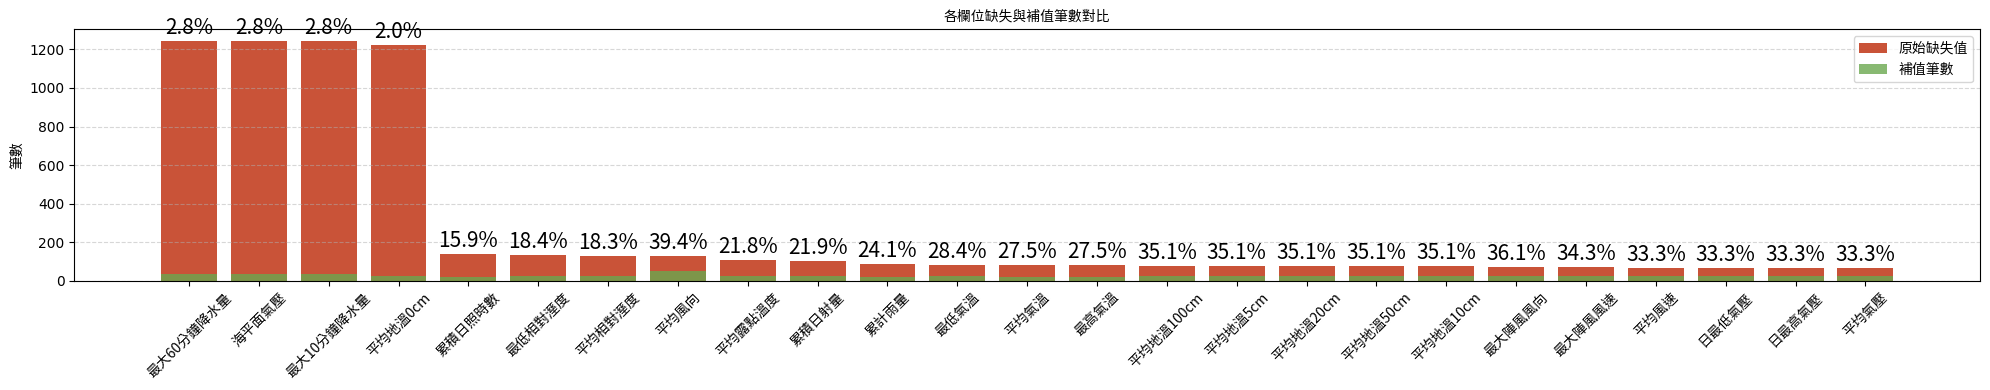

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# ✅ 嘗試載入常見的繁體中文字體
font_path = None
for font_name in ["Microsoft JhengHei", "Noto Sans CJK TC", "Arial Unicode MS"]:
    try:
        font_path = fm.findfont(font_name, fallback_to_default=False)
        break
    except:
        continue

# 若無法載入，使用預設字體
font_prop = fm.FontProperties(fname=font_path) if font_path else fm.FontProperties()

# 建立欄位與缺失/補值筆數對照表
data = {
    "欄位": [
        "平均氣壓", "海平面氣壓", "日最高氣壓", "日最低氣壓", "平均氣溫", "最高氣溫", "最低氣溫",
        "平均露點溫度", "平均相對溼度", "最低相對溼度", "平均風速", "平均風向", "最大陣風風速",
        "最大陣風風向", "累計雨量", "最大10分鐘降水量", "最大60分鐘降水量", "累積日照時數",
        "累積日射量", "平均地溫0cm", "平均地溫5cm", "平均地溫10cm",
        "平均地溫20cm", "平均地溫50cm", "平均地溫100cm"
    ],
    "原始缺失值": [
        69, 1242, 69, 69, 80, 80, 81, 110, 131, 136, 69, 127, 70,
        72, 87, 1242, 1242, 138, 105, 1223, 77, 77, 77, 77, 77
    ],
    "補值筆數": [
        23, 35, 23, 23, 22, 22, 23, 24, 24, 25, 23, 50, 24,
        26, 21, 35, 35, 22, 23, 24, 27, 27, 27, 27, 27
    ]
}

df = pd.DataFrame(data)
df["補值率 (%)"] = (df["補值筆數"] / df["原始缺失值"] * 100).round(1)
df = df.sort_values(by="原始缺失值", ascending=False)

# 畫圖
plt.figure(figsize=(20, 4))
bars1 = plt.bar(df["欄位"], df["原始缺失值"], label="原始缺失值", alpha=0.8, color="#bc2806")
bars2 = plt.bar(df["欄位"], df["補值筆數"], label="補值筆數", alpha=0.8, color="#6aa84f")

# 標註補值率
for i, bar in enumerate(bars1):
    height = bar.get_height()
    ratio = df["補值率 (%)"].iloc[i]
    plt.text(bar.get_x() + bar.get_width()/2, height + 10, f"{ratio}%", 
             ha='center', va='bottom', fontsize=15, fontproperties=font_prop)

plt.xticks(rotation=45, fontproperties=font_prop)
plt.ylabel("筆數", fontproperties=font_prop)
plt.title("各欄位缺失與補值筆數對比", fontsize=100, fontproperties=font_prop)
plt.legend(prop=font_prop)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# 儲存透明背景圖
plt.savefig("image/emissing_values_comparison.png", transparent=True, dpi=600)
plt.show()


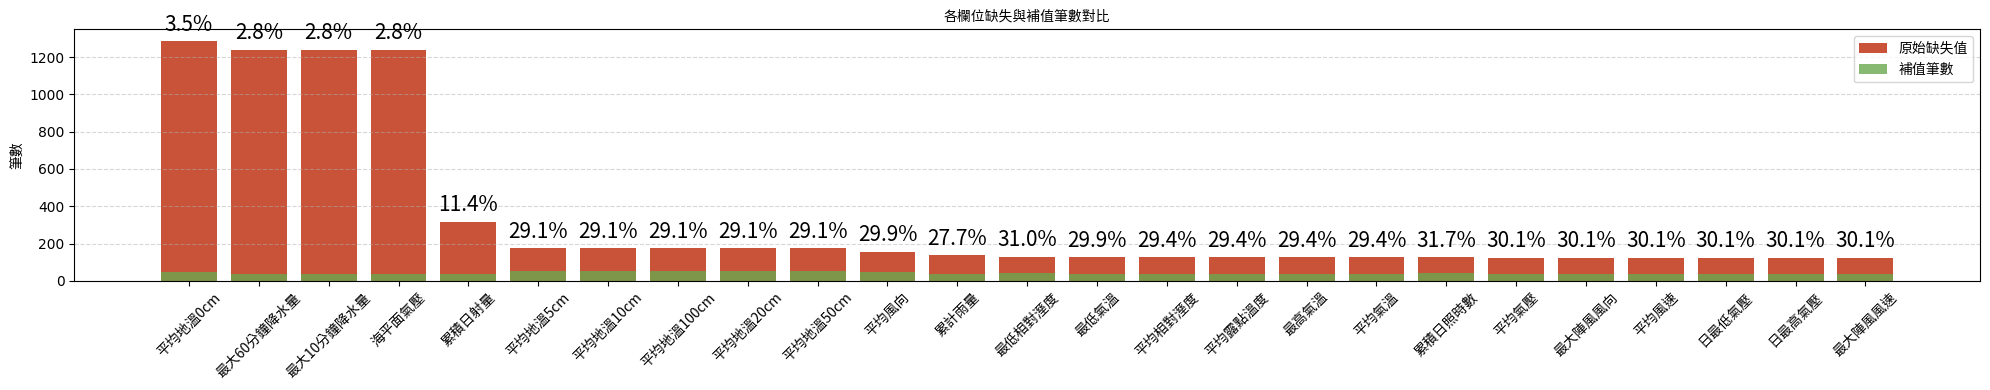

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 嘗試載入常見繁體中文字體
font_path = None
for font_name in ["Microsoft JhengHei", "Noto Sans CJK TC", "Arial Unicode MS"]:
    try:
        font_path = fm.findfont(font_name, fallback_to_default=False)
        break
    except:
        continue
font_prop = fm.FontProperties(fname=font_path) if font_path else fm.FontProperties()

# 新資料
data = {
    "欄位": [
        "平均氣壓", "海平面氣壓", "日最高氣壓", "日最低氣壓", "平均氣溫", "最高氣溫", "最低氣溫",
        "平均露點溫度", "平均相對溼度", "最低相對溼度", "平均風速", "平均風向", "最大陣風風速",
        "最大陣風風向", "累計雨量", "最大10分鐘降水量", "最大60分鐘降水量", "累積日照時數",
        "累積日射量",  "平均地溫0cm", "平均地溫5cm", "平均地溫10cm",
        "平均地溫20cm", "平均地溫50cm", "平均地溫100cm"
    ],
    "原始缺失值": [
        123, 1239, 123, 123, 126, 126, 127, 126, 126, 129, 123, 157, 123,
        123, 137, 1239, 1239, 126, 317,  1285, 175, 175, 175, 175, 175
    ],
    "補值筆數": [
        37, 35, 37, 37, 37, 37, 38, 37, 37, 40, 37, 47, 37,
        37, 38, 35, 35, 40, 36, 45, 51, 51, 51, 51, 51
    ]
}
df = pd.DataFrame(data)
df["補值率 (%)"] = (df["補值筆數"] / df["原始缺失值"] * 100).round(1)
df = df.sort_values(by="原始缺失值", ascending=False)

# 畫圖
plt.figure(figsize=(20, 4))
bars1 = plt.bar(df["欄位"], df["原始缺失值"], label="原始缺失值", alpha=0.8, color="#bc2806")
bars2 = plt.bar(df["欄位"], df["補值筆數"], label="補值筆數", alpha=0.8, color="#6aa84f")

# 中文標籤與補值率顯示
plt.xticks(rotation=45, fontproperties=font_prop)
plt.ylabel("筆數", fontproperties=font_prop)
plt.title("各欄位缺失與補值筆數對比", fontsize=14, fontproperties=font_prop)
plt.legend(prop=font_prop)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 補值率顯示在紅色柱狀圖上方
for i, bar in enumerate(bars1):
    height = bar.get_height()
    ratio = df["補值率 (%)"].iloc[i]
    plt.text(bar.get_x() + bar.get_width()/2, height + 30, f"{ratio}%",
             ha='center', va='bottom', fontsize=15, fontproperties=font_prop)

plt.tight_layout()
plt.savefig("image/missing_values_comparison_v2.png", transparent=True, dpi=600)
plt.show()


/var/folders/pb/n0kw36_147s6yq9c0f4c2cs40000gn/T/ipykernel_47676/1979880235.py:52: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from current font.
  plt.tight_layout()
/var/folders/pb/n0kw36_147s6yq9c0f4c2cs40000gn/T/ipykernel_47676/1979880235.py:52: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from current font.
  plt.tight_layout()
/var/folders/pb/n0kw36_147s6yq9c0f4c2cs40000gn/T/ipykernel_47676/1979880235.py:52: UserWarning: Glyph 39080 (\N{CJK UNIFIED IDEOGRAPH-98A8}) missing from current font.
  plt.tight_layout()
/var/folders/pb/n0kw36_147s6yq9c0f4c2cs40000gn/T/ipykernel_47676/1979880235.py:52: UserWarning: Glyph 36895 (\N{CJK UNIFIED IDEOGRAPH-901F}) missing from current font.
  plt.tight_layout()
/var/folders/pb/n0kw36_147s6yq9c0f4c2cs40000gn/T/ipykernel_47676/1979880235.py:52: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from current font.
  plt.tight_layout()
/var/folders/pb/n0kw36_147s6yq9c0f4c2cs40000gn/T/ipyker

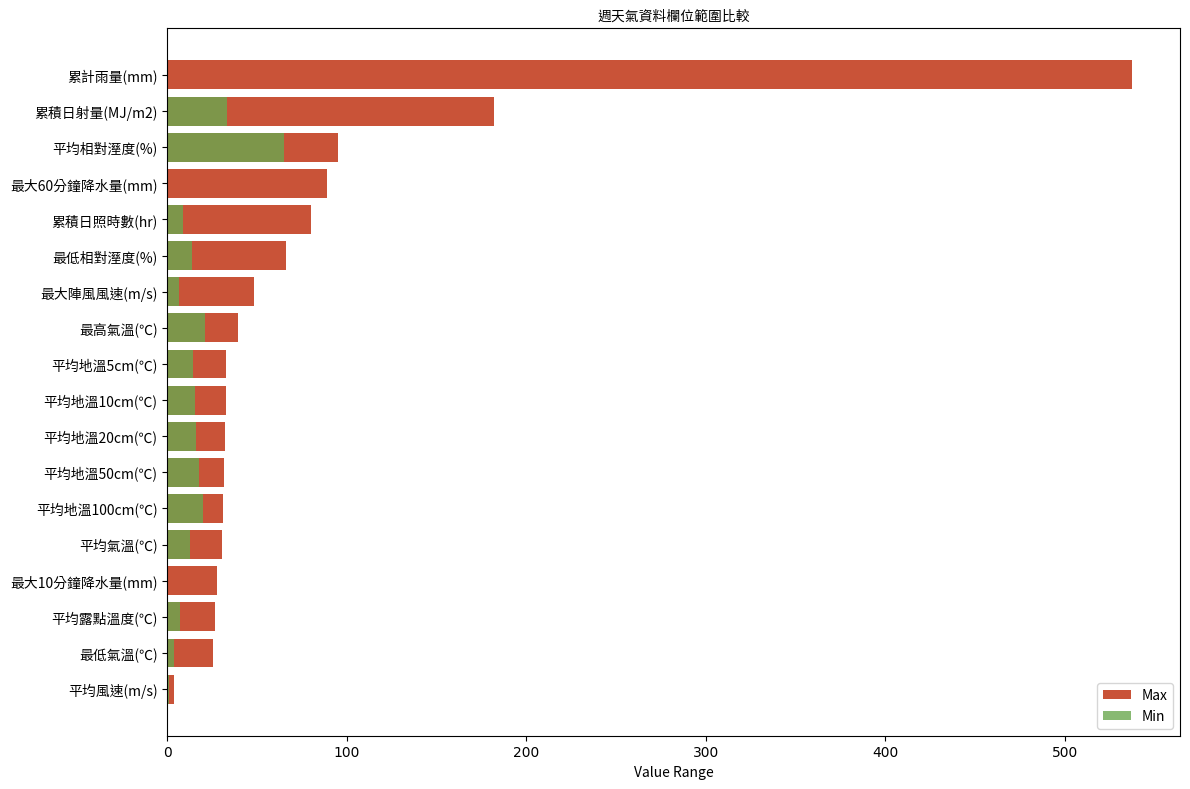

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

# 嘗試載入常見繁體中文字體
font_path = None
for font_name in ["Microsoft JhengHei", "Noto Sans CJK TC", "Arial Unicode MS"]:
    try:
        font_path = fm.findfont(font_name, fallback_to_default=False)
        break
    except:
        continue
font_prop = fm.FontProperties(fname=font_path) if font_path else fm.FontProperties()

# 資料輸入
data = {
    "Variable": [
         "平均氣溫(℃)", "最高氣溫(℃)", "最低氣溫(℃)",
        "平均露點溫度(℃)", "平均相對溼度(%)", "最低相對溼度(%)", "平均風速(m/s)", "最大陣風風速(m/s)",
        "累計雨量(mm)", "最大10分鐘降水量(mm)", "最大60分鐘降水量(mm)", "累積日照時數(hr)", "累積日射量(MJ/m2)",
        "平均地溫5cm(℃)", "平均地溫10cm(℃)", "平均地溫20cm(℃)", "平均地溫50cm(℃)", "平均地溫100cm(℃)"
    ],
    "Missing_Values": [  0, 0, 0,
        0, 0, 0, 0, 0,
        5, 170, 170, 4, 10,
        0, 0, 0, 0, 0
    ],
    "Min": [
         12.882143, 21.2, 3.5,
        6.964286, 64.928571, 14.0, 0.907143, 6.7,
        0.0, 0.0, 0.0, 8.8, 33.155,
        14.371429, 15.228571, 15.878571, 17.707143, 19.807143
    ],
    "Max": [
         30.564286, 39.2, 25.5,
        26.492857, 94.928571, 66.0, 3.814286, 48.2,
        537.25, 28.0, 89.0, 80.15, 182.23,
        32.807143, 32.464286, 32.2, 31.521429, 30.9
    ]
}

df_summary = pd.DataFrame(data)
df_summary = df_summary.sort_values(by="Max", ascending=True)

# 圖表：變數最大值與最小值比較（前20項）
fig, ax = plt.subplots(figsize=(12, 8))
subset = df_summary.head(20)
ax.barh(subset["Variable"], subset["Max"], label='Max', alpha=0.8, color = '#bc2806')
ax.barh(subset["Variable"], subset["Min"], label='Min', alpha=0.8, color="#6aa84f")
ax.set_xlabel("Value Range", fontproperties=font_prop)
ax.set_title("週天氣資料欄位範圍比較", fontproperties=font_prop)
ax.legend(prop=font_prop,loc = 'lower right' )
plt.tight_layout()
plt.yticks( fontproperties=font_prop)

plt.tight_layout()
plt.savefig("image/missing_values_comparison_v3.png", transparent=True, dpi=600)

plt.show()
